In [21]:
import yfinance as yf
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

In [2]:
stock = yf.Ticker('FICO')

In [3]:
def financial_statements(ticker):
    income_yearly = ticker.get_income_stmt()
    income_yearly = income_yearly.transpose()
    income_quarterly = ticker.get_income_stmt(freq='quarterly')
    income_quarterly = income_quarterly.transpose()
    balance_yearly = ticker.get_balance_sheet()
    balance_yearly = balance_yearly.transpose()
    balance_quarterly = ticker.get_balance_sheet(freq='quarterly')
    balance_quarterly = balance_quarterly.transpose()
    cashflow_yearly = ticker.get_cash_flow()
    cashflow_yearly = cashflow_yearly.transpose()
    cashflow_quarterly = ticker.get_cash_flow(freq='quarterly')
    cashflow_quarterly = cashflow_quarterly.transpose()
    return income_yearly, income_quarterly, balance_yearly, balance_quarterly, cashflow_yearly, cashflow_quarterly
income_y, income_q, balance_y, balance_q, cashflow_y, cashflow_q = financial_statements(ticker=stock)

In [4]:
def useful_variables(year_data, quarter_data):
    years = year_data.index.tolist()
    years = [d.strftime('%Y-%m-%d') for d in years]
    quarters = quarter_data.index.to_period('Q').astype(str)
    return years, quarters
years, quarters = useful_variables(income_y, income_q)

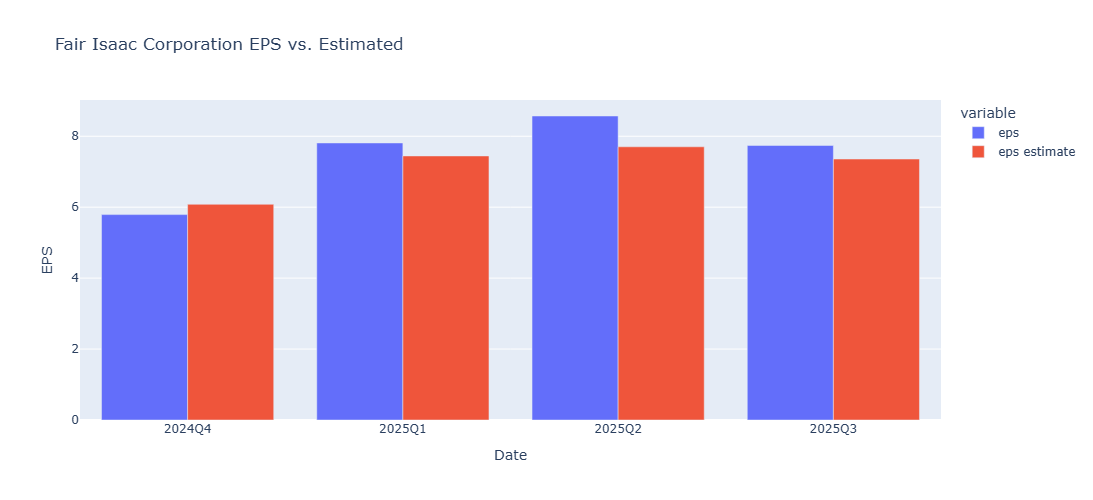

In [19]:
def actual_vs_estimate(ticker):
    historic = ticker.get_earnings_history()
    df_historic = pd.DataFrame(historic)
    # Convert to quarters for a cleaner looking xaxis
    df_historic.index = df_historic.index.to_period('Q').astype(str)
    df_historic = df_historic.reset_index()
    df_historic = df_historic.rename(columns={'epsActual': 'eps', 'epsEstimate': 'eps estimate'})
    historic_bar = px.bar(df_historic, x='quarter', y=['eps', 'eps estimate'],
                          title=f'{ticker.info['shortName']} EPS vs. Estimated', barmode='group', height=500)
    historic_bar.update_layout(xaxis_title='Date', yaxis_title='EPS')
    
    return df_historic, historic_bar
history, chart = actual_vs_estimate(ticker=stock)
chart

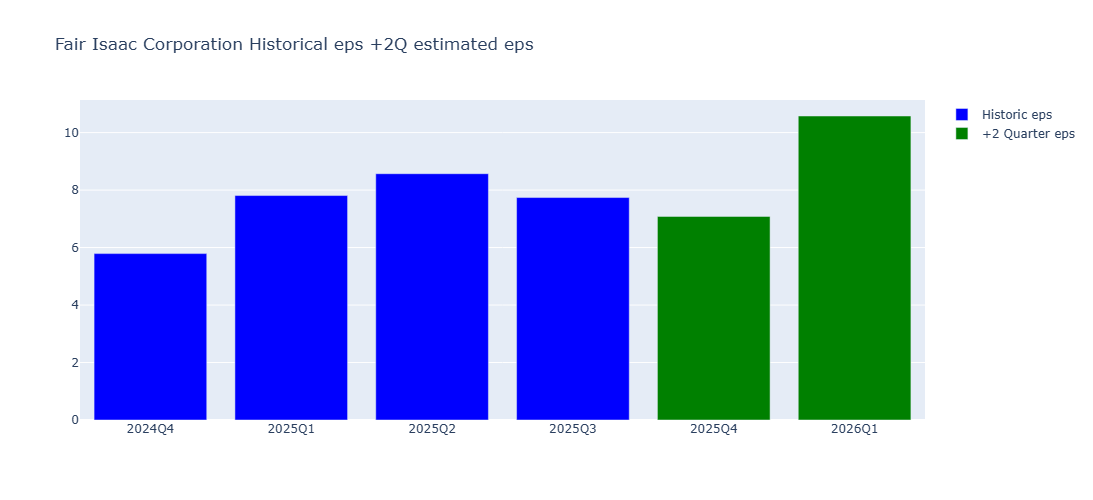

In [24]:
def future_eps(ticker, eps_previous):
    # Obtain only previous eps data from history dataframe
    eps_previous = eps_previous[['quarter', 'eps']]  
    # Obtain eps estimates for the next 2 quarters
    estimates = stock.get_earnings_estimate()
    estimates = estimates.reset_index()
    estimates = estimates.rename(columns={'period': 'quarter', 'avg': 'eps'})
    eps_estimate = estimates[['quarter', 'eps']]
    # Drop eps year data
    eps_estimate = eps_estimate.drop([2, 3])
    # Clean up eps_estimate column data
    eps_estimate.loc[0, 'quarter'] = '2025Q4'
    eps_estimate.loc[1, 'quarter'] = '2026Q1'
    # Combine historical and estimates
    # eps_combined = pd.concat([eps, eps_estimate], ignore_index=True)

    # Plot data
    eps_bar = go.Figure()
    eps_bar.add_trace(go.Bar(x=eps_previous.quarter, y=eps_previous.eps,
                             marker_color='blue', name='Historic eps'))
    eps_bar.add_trace(go.Bar(x=eps_estimate.quarter, y=eps_estimate.eps,
                             marker_color='green', name='+2 Quarter eps'))
    eps_bar.update_layout(title_text=f'{ticker.info['shortName']} Historical eps +2Q estimated eps', 
                         height=500)
    # eps_bar.show()
    # eps_bar = px.bar(eps_combined, x='quarter', y='eps',
    #                       title=f'{ticker.info['shortName']} Historical EPS with predicted future EPS', height=500)
    # eps_bar.update_layout(xaxis_title='Quarter', yaxis_title='EPS')
    
    return eps_bar
future_eps(ticker=stock, eps_previous=history)